# Fake News Detection with DistilBERT

Group 01
- Alonso Geesink Anton ()
- Claudio Vincenzo Catalano Leiva (claudio.catalano.leiva@alumnos.upm.es)
- Seyit Ahmet Inci ()

Deep Learning Course 2025/26 - Course Project: Exercise 2 - Fine-tuning the Model with Experimentation

**Dataset**: [Fake News Detection Datasets](https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets/data)

**Code References using DistilBERT**:
- https://www.kaggle.com/code/henryukwuoma/fake-and-real-news-distilbert
- https://www.kaggle.com/code/shehabmagdy710/distilbert-fine-tuning-on-fake-news-data

## 1. Setup and Imports

The cell below contains package installations that you should do whenever you first use this Jupyter notebook. Additionally, remember to download the dataset files (true.csv & fake.csv) and place them on a new folder named **data**.

In [37]:
# Install required packages if needed
# !pip install transformers datasets torch pandas numpy scikit-learn matplotlib seaborn tqdm accelerate

### 1.1. Initial Setup and Imports

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from tqdm.auto import tqdm
import json
import os
from pathlib import Path
from datetime import datetime
import time

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility for torch and numpy in our machines
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration -> In our case since we have a transformer mode if you guys have a gpu to use it will be faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using the following device for our training: {device}')

Using the following device for our training: cpu


## 2. Loading the Data from the Kaggle Dataset

Note: Before running this for our training, remember to check that the data files are in your local folder! You can find them from the dataset from Kaggle and place the CSV files in a `data/` directory.
Expected files:
- `Fake.csv`: Contains fake news articles
- `True.csv`: Contains true news articles

In [3]:
# Load the dataset which is split into two files: Fake.csv and True.csv
fake_df = pd.read_csv('data/Fake.csv')
true_df = pd.read_csv('data/True.csv')

# Add labels: 0 for fake, 1 for true
fake_df['label'] = 0
true_df['label'] = 1

# Combine the datasets so that we just have one file
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset to ensure random distribution for our training
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Basic info about the dataset
print(f"Total samples: {len(df)}")
print(f"Fake news: {len(fake_df)} ({len(fake_df)/len(df)*100:.2f}%)")
print(f"True news: {len(true_df)} ({len(true_df)/len(df)*100:.2f}%)")
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Display first few rows
print("\nFirst few rows of the dataset: ")
df.head()

Total samples: 44898
Fake news: 23481 (52.30%)
True news: 21417 (47.70%)

Dataset shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

First few rows of the dataset: 


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


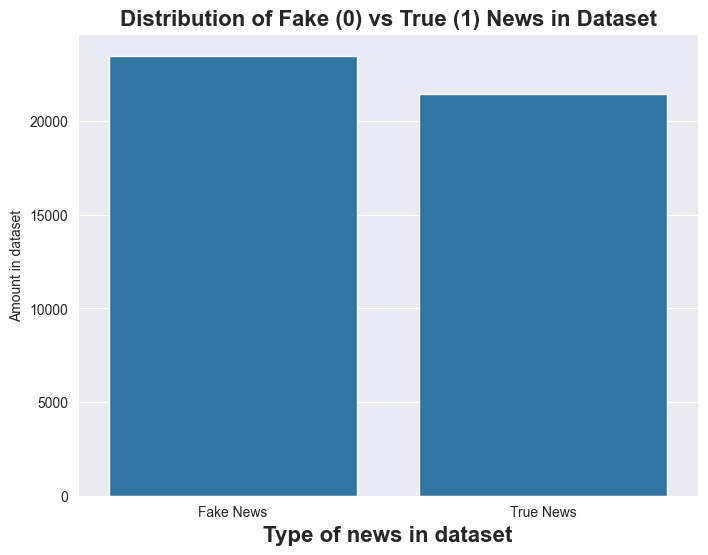

In [4]:
# Visualization of the dataset with label distribution using a count plot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label')
plt.title('Distribution of Fake (0) vs True (1) News in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Type of news in dataset', fontsize=16, fontweight='bold')
plt.ylabel('Amount in dataset')
plt.xticks([0, 1], ['Fake News', 'True News'])
plt.show()

## 3. Data Preprocessing

In this section, we will preprocess the data to prepare it for training. This includes combining relevant text fields and splitting the dataset into training, validation, and test sets that will be used later for model training and evaluation.

In [5]:
# Combining the  title and text (if they exist) for better context in our model training
if 'title' in df.columns and 'text' in df.columns:
    df['content'] = df['title'] + ' ' + df['text']
elif 'text' in df.columns:
    df['content'] = df['text']
elif 'title' in df.columns:
    df['content'] = df['title']
else:
    # Find the text column
    text_cols = [col for col in df.columns if col not in ['label', 'subject', 'date']]
    if text_cols:
        df['content'] = df[text_cols[0]]
    else:
        raise ValueError("Could not find text column in dataset")

print(f"Average content length: {df['content'].str.len().mean():.0f} characters")

Average content length: 2550 characters


In [6]:
# First split: 85% train+val, 15% test
train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['label']
)

# Second split: 82.35% train, 17.65% val from the train+val set
train_df, val_df = train_test_split(
    train_val_df, test_size=0.1765, random_state=SEED, stratify=train_val_df['label']
)

print(f"Training set size (70%): {len(train_df)}")
print(f"Validation set size (15%): {len(val_df)}")
print(f"Test set size (15%): {len(test_df)}")

Training set size (70%): 31427
Validation set size (15%): 6736
Test set size (15%): 6735


## 3.5 - Defining the configurations

In order to fine-tune our DistilBERT model for fake news detection, we will experiment with different hyperparameter configurations. Below are the configurations we will use for training, each with a unique combination of the following 3 hyperparameters: epochs, learning rate, and weight decay.

**Combinations:**
- **Config 1:** epochs=1, learning_rate=4e-5, weight_decay=0.00
- **Config 2:** epochs=2, learning_rate=3e-5, weight_decay=0.01
- **Config 3:** epochs=2, learning_rate=3e-5, weight_decay=0.005
- **Config 4:** epochs=3, learning_rate=2e-5, weight_decay=0.01
- **Config 5:** epochs=3, learning_rate=2e-5, weight_decay=0.015
- **Config 6:** epochs=4, learning_rate=1.5e-5, weight_decay=0.02

In [7]:
# Global training constants -> batch size and output directory to save results
BATCH_SIZE = 32
MAX_LENGTH = 128
OUTPUT_DIR = Path("DL_Milestone2_experiments")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# List of configurations with the following hyperparameters: epochs, learning_rate, weight_decay
configs = [
    {"name": "1", "epochs": 1,  "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 4e-5,  "weight_decay": 0.00},
    {"name": "2", "epochs": 2, "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 3e-5,  "weight_decay": 0.01},
    {"name": "3", "epochs": 2,  "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 3e-5,  "weight_decay": 0.005},
    {"name": "4", "epochs": 3, "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 2e-5,"weight_decay": 0.01},
    {"name": "5", "epochs": 3, "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 2e-5,  "weight_decay": 0.015},
    {"name": "6", "epochs": 4,  "per_device_train_batch_size": BATCH_SIZE, "learning_rate": 1.5e-5,  "weight_decay": 0.02},
]

print("Loaded configurations for training:")
for cfg in configs:
    print(cfg)

Loaded configurations for training:
{'name': '1', 'epochs': 1, 'per_device_train_batch_size': 32, 'learning_rate': 4e-05, 'weight_decay': 0.0}
{'name': '2', 'epochs': 2, 'per_device_train_batch_size': 32, 'learning_rate': 3e-05, 'weight_decay': 0.01}
{'name': '3', 'epochs': 2, 'per_device_train_batch_size': 32, 'learning_rate': 3e-05, 'weight_decay': 0.005}
{'name': '4', 'epochs': 3, 'per_device_train_batch_size': 32, 'learning_rate': 2e-05, 'weight_decay': 0.01}
{'name': '5', 'epochs': 3, 'per_device_train_batch_size': 32, 'learning_rate': 2e-05, 'weight_decay': 0.015}
{'name': '6', 'epochs': 4, 'per_device_train_batch_size': 32, 'learning_rate': 1.5e-05, 'weight_decay': 0.02}


## 4. Tokenization and Dataset Preparation

In [8]:
# Load DistilBERT tokenizer
# Note: Using AutoTokenizer for better compatibility
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")

Tokenizer loaded: distilbert-base-uncased


In [9]:
# Define custom dataset class for our train, val, test sets
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens = True,
            max_length = self.max_length,
            padding = 'max_length',
            truncation = True,
            return_attention_mask = True,
            return_tensors = 'pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [10]:
# Create datasets for train, val, test
train_dataset = FakeNewsDataset(
    texts = train_df['content'].values,
    labels = train_df['label'].values,
    tokenizer = tokenizer,
    max_length = MAX_LENGTH
)

val_dataset = FakeNewsDataset(
    texts = val_df['content'].values,
    labels = val_df['label'].values,
    tokenizer = tokenizer,
    max_length = MAX_LENGTH
)

test_dataset = FakeNewsDataset(
    texts = test_df['content'].values,
    labels = test_df['label'].values,
    tokenizer = tokenizer,
    max_length = MAX_LENGTH
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 983
Number of validation batches: 211
Number of test batches: 211


## 5. Model Setup

In [11]:
# Load pre-trained DistilBERT model with 2 output labels (fake, true)
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

print(f"Model loaded and moved to {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and moved to cpu
Number of parameters: 66,955,010


## 6. Training Functions

In this implementation of the training loop, we define two key functions: `train_epoch` and `eval_model`. The `train_epoch` function handles the training process for one epoch, including forward and backward passes, loss calculation, and accuracy tracking. The `eval_model` function evaluates the model's performance on the validation or test set without updating the model weights. Both functions utilize progress bars for better visualization of the training and evaluation processes.

We are not using huggingface's Trainer API to have more control over the training loop and to facilitate custom logging and metric tracking.

In [12]:
# This function trains the model for one epoch
def train_epoch(model, data_loader, optimizer, scheduler, device):

    # Set model to training mode
    model.train()

    # Initialize tracking variables
    losses = []
    correct_predictions = 0
    total_predictions = 0

    # Progress bar for visualization
    progress_bar = tqdm(data_loader, desc='Training')

    # Iterate over the batches in the data loader
    for batch in progress_bar:

        # Move the batch to the specified device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass part of the training
        outputs = model(
            input_ids = input_ids,
            attention_mask = attention_mask,
            labels = labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Calculate accuracy for the batch
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_predictions += labels.size(0)
        losses.append(loss.item())
        
        # Update progress bar with current loss and accuracy
        progress_bar.set_postfix({
            'loss': loss.item(),
            'acc': (correct_predictions.double() / total_predictions).item()
        })
    
    return correct_predictions.double() / total_predictions, np.mean(losses)

In [13]:
# This function evaluates the model on the validation/test set. This does not update model weights and is done after each training epoch.
def eval_model(model, data_loader, device):

    # Set model to evaluation mode
    model.eval()

    # Initialize tracking variables
    losses = []
    correct_predictions = 0
    total_predictions = 0
    all_preds = []
    all_labels = []

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Evaluating')

        # Iterate over the batches in the data loader
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids = input_ids,
                attention_mask = attention_mask,
                labels = labels
            )
            
            loss = outputs.loss
            logits = outputs.logits

            # Calculate accuracy for the batch
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total_predictions += labels.size(0)
            losses.append(loss.item())

            # Store all predictions and labels for further analysis
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (
        correct_predictions.double() / total_predictions,
        np.mean(losses),
        np.array(all_preds),
        np.array(all_labels)
    )

In [14]:
# This function sets up the optimizer and scheduler for each configuration
def setup_optimizer_and_scheduler(model, train_loader, learning_rate, weight_decay, epochs):
    optimizer = AdamW(model.parameters(), lr=learning_rate, eps=1e-8, weight_decay=weight_decay)

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    print(f"Total training steps: {total_steps}")
    return optimizer, scheduler

# Function to save run results so we can later analyze on SPSS
def save_run_result(run_metadata: dict, metrics: dict, filename: str = None):
    payload = {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "config": run_metadata,
        "metrics": metrics
    }
    if filename is None:
        safe_name = f"run_{run_metadata['name']}_e{run_metadata['epochs']}_lr{run_metadata['learning_rate']}_wd{run_metadata['weight_decay']}.json"
        filename = OUTPUT_DIR / safe_name
    else:
        filename = OUTPUT_DIR / filename
    with open(filename, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved results to {filename}")

## 7. Training Loop

In our training loop, we can first define the config that we want to make the 5 runs of. These runs will be independent of each other, meaning that for each run we will reload the model and optimizer to ensure that the training starts from the same initial state. This is crucial for obtaining unbiased results when evaluating the performance of different hyperparameter configurations.

Since we want to do 15 runs per configuration (5 runs each team member), we will loop over the number of runs and for each run, we will train the model for the specified number of epochs defined in the configuration. After training, we will evaluate the model on the validation set and save the best model based on validation accuracy.

In [15]:
# Training Loop over configurations
all_results = []

# Configuration selection -> Remember to change this to run different configurations!!!!
config_num = 1
cfg = configs[config_num - 1]

# Making another folder for each configuration to save the results
config_dir = OUTPUT_DIR / f"cfg{config_num}"
config_dir.mkdir(exist_ok=True, parents=True)

print("="*50)
print(f"Starting run for config {cfg['name']} | epochs={cfg['epochs']}, lr={cfg['learning_rate']}, wd={cfg['weight_decay']}, batch_size={cfg['per_device_train_batch_size']}, on device={device} with max length={MAX_LENGTH}")
print("="*50)

# Run 5 independent training runs for each config -> 5 runs each team member so we get 15 per configuration
for run in range(1, 6):
    print("-" * 40)
    print(f"Run {run}/5 for config {cfg['name']}")
    print("-" * 40)

    run_start_time = time.time()

    # Here we reload our model and optimizer for each run to ensure independence
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(device)

    optimizer, scheduler = setup_optimizer_and_scheduler(
        model,
        train_loader,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        epochs=cfg['epochs'],
    )

    # Initialize history tracking
    history = {
        "train_acc": [],
        "train_loss": [],
        "val_acc": [],
        "val_loss": [],
    }
    epoch_times = []
    best_val_acc = 0

    # Train for the specified number of epochs
    for epoch in range(cfg['epochs']):
        print(f"Epoch {epoch + 1}/{cfg['epochs']}")

        epoch_start_time = time.time()

        train_acc, train_loss = train_epoch(
            model, train_loader, optimizer, scheduler, device
        )
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

        val_acc, val_loss, _, _ = eval_model(
            model, val_loader, device
        )
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time
        epoch_times.append(epoch_duration)
        print(f"Epoch time: {epoch_duration:.2f} seconds")

        history["train_acc"].append(train_acc.item())
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc.item())
        history["val_loss"].append(val_loss)

        # Save best model for this run
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = config_dir / f"bestmodel_{cfg['name']}_run{run}.pt"
            torch.save(model.state_dict(), model_path)
            print(f"> Best model saved with validation accuracy {best_val_acc:.4f}")

    run_end_time = time.time()
    run_duration = run_end_time - run_start_time
    print(f"Run time: {run_duration:.2f} seconds")

    # Save run results
    metrics = {
        "history": history,
        "epoch_times": epoch_times,
        "run_time": run_duration,
        "best_val_acc": best_val_acc.item() if hasattr(best_val_acc, "item") else best_val_acc
    }
    save_run_result (
        run_metadata = cfg,
        metrics = metrics,
        filename = f"run_{cfg['name']}_{run}.json"
    )

    all_results.append({"config": cfg, "metrics": metrics})

Starting run for config 1 | epochs=1, lr=4e-05, wd=0.0
----------------------------------------
Run 1/5 for config 1
----------------------------------------


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total training steps: 983
Epoch 1/1


Training:   0%|          | 0/983 [00:00<?, ?it/s]

Train Loss: 0.0118 | Train Acc: 0.9967


...

Val Loss: 0.0051 | Val Acc: 0.9991
> Best model saved with validation accuracy 0.9991
Saved results to DL_Milestone2_experiments/run_1_2.json
----------------------------------------
Run 3/5 for config 1
----------------------------------------


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total training steps: 983
Epoch 1/1


Training:   0%|          | 0/983 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 8. Save Model and Tokenizer (for the chosen one)

In [ ]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model and tokenizer
model.save_pretrained('models/fake_news_distilbert')
tokenizer.save_pretrained('models/fake_news_distilbert')

print('Model and tokenizer saved to models/fake_news_distilbert/')